In [1]:
!pip install -q datasets streamlit pandas matplotlib seaborn
!npm install -g localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 67.1 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋
added 22 packages in 3s
⠋
⠋3 packages are looking for funding
⠋  run `npm fund` for details
⠋

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from datasets import load_dataset


sst2 = load_dataset('nyu-mll/glue', 'sst2')
sst2_train = sst2["train"]
sst2_val = sst2["validation"]


mrpc = load_dataset('nyu-mll/glue', 'mrpc')
mrpc_train = mrpc["train"]
mrpc_val = mrpc["validation"]

qqp = load_dataset("nyu-mll/glue", "qqp")
qqp_train = qqp["train"]
qqp_val = qqp["validation"]

mnli = load_dataset("nyu-mll/glue", "mnli")
mnli_train = mnli["train"]
mnli_val = mnli["validation_matched"]

README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

sst2/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.11MB            

sst2/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sst2/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 72.8kB            

sst2/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/392702 [00:00<?, ? examples/s]

Generating validation_matched split:   0%|          | 0/9815 [00:00<?, ? examples/s]

Generating validation_mismatched split:   0%|          | 0/9832 [00:00<?, ? examples/s]

Generating test_matched split:   0%|          | 0/9796 [00:00<?, ? examples/s]

Generating test_mismatched split:   0%|          | 0/9847 [00:00<?, ? examples/s]

In [3]:
import pandas as pd

sst2_train = pd.DataFrame(sst2_train)
sst2_val = pd.DataFrame(sst2_val)

mrpc_train = pd.DataFrame(mrpc_train)
mrpc_val = pd.DataFrame(mrpc_val)

qqp_train = pd.DataFrame(qqp_train)
qqp_val = pd.DataFrame(qqp_val)

mnli_train = pd.DataFrame(mnli_train)
mnli_val = pd.DataFrame(mnli_val)

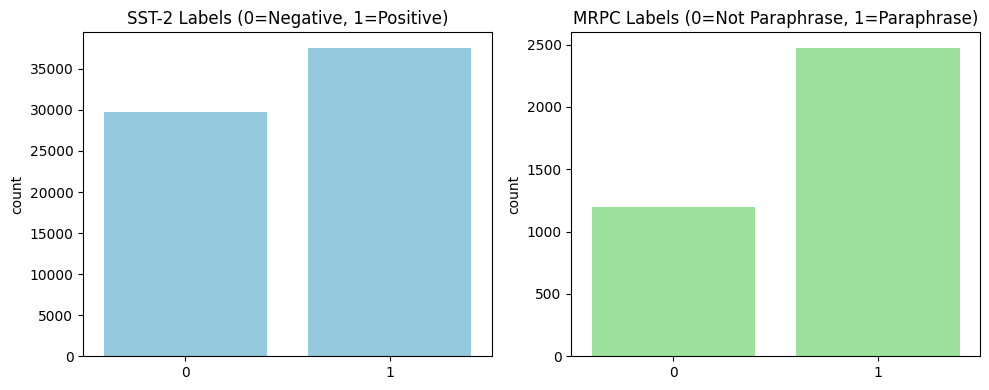

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x=sst2['train']['label'], ax=axes[0], color='skyblue')
axes[0].set_title('SST-2 Labels (0=Negative, 1=Positive)')

sns.countplot(x=mrpc['train']['label'], ax=axes[1], color='lightgreen')
axes[1].set_title('MRPC Labels (0=Not Paraphrase, 1=Paraphrase)')
plt.tight_layout()
plt.show()

In [7]:
import nltk
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [10]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
stop_words = set(stopwords.words("english"))

negation_words = {
    "no", "nor", "not",
    "don't", "didn't", "doesn't",
    "isn't", "aren't", "wasn't", "weren't",
    "haven't", "hasn't", "hadn't",
    "won't", "wouldn't", "can't", "couldn't",
    "shouldn't", "mustn't",
    "never"
}

stop_words = stop_words - negation_words

lemmatizer = WordNetLemmatizer()

In [11]:
def preprocess(text):

    if pd.isna(text):
        return []

    # lowercase
    text = text.lower()

    # Expand contractions
    contractions = {
        "can't": "can not",
        "won't": "will not",
        "n't": " not",
        "'re": " are",
        "'ve": " have",
        "'ll": " will",
        "'d": " would",
        "'m": " am",
        "'s": " is"
    }

    for k, v in contractions.items():
        text = text.replace(k, v)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove HTML
    text = re.sub(r"<.*?>", " ", text)

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Keep only letters
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenization
    tokens = text.split()

    # Remove stopwords (except negation)
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return tokens

In [12]:
sst2_train["sentence"] = sst2_train["sentence"].apply(preprocess)
sst2_val["sentence"] = sst2_val["sentence"].apply(preprocess)

mrpc_train["sentence1"] = mrpc_train["sentence1"].apply(preprocess)
mrpc_train["sentence2"] = mrpc_train["sentence2"].apply(preprocess)
mrpc_val["sentence1"] = mrpc_val["sentence1"].apply(preprocess)
mrpc_val["sentence2"] = mrpc_val["sentence2"].apply(preprocess)

qqp_train["question1"] = qqp_train["question1"].apply(preprocess)
qqp_train["question2"] = qqp_train["question2"].apply(preprocess)
qqp_val["question1"] = qqp_val["question1"].apply(preprocess)
qqp_val["question2"] = qqp_val["question2"].apply(preprocess)

mnli_train["premise"] = mnli_train["premise"].apply(preprocess)
mnli_train["hypothesis"] = mnli_train["hypothesis"].apply(preprocess)
mnli_val["premise"] = mnli_val["premise"].apply(preprocess)
mnli_val["hypothesis"] = mnli_val["hypothesis"].apply(preprocess)

In [13]:
# SST-2
sst2_train.dropna(inplace=True)
sst2_val.dropna(inplace=True)

# MRPC
mrpc_train.dropna(inplace=True)
mrpc_val.dropna(inplace=True)

# QQP
qqp_train.dropna(inplace=True)
qqp_val.dropna(inplace=True)

# MNLI
mnli_train.dropna(inplace=True)
mnli_val.dropna(inplace=True)

In [14]:
datasets = [
    sst2_train, sst2_val,
    mrpc_train, mrpc_val,
    qqp_train, qqp_val,
    mnli_train, mnli_val
]

for df in datasets:
    df.reset_index(drop=True, inplace=True)

In [15]:
print("SST-2 Train:", sst2_train.shape)
print("MRPC Train:", mrpc_train.shape)
print("QQP Train:", qqp_train.shape)
print("MNLI Train:", mnli_train.shape)

SST-2 Train: (67349, 3)
MRPC Train: (3668, 4)
QQP Train: (363846, 4)
MNLI Train: (392702, 4)


In [16]:
!pip install -q gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.1 MB/s eta 0:00:00


In [17]:
# ===========================
# Install & Import
# ===========================
import gensim.downloader as api
import numpy as np
import re

# ===========================
# Tokenize all datasets
# ===========================

print("Tokenizing datasets...")

sst2_tokens = sst2_train["sentence"].tolist()

mrpc_tokens = [
    s1 + ["<SEP>"] + s2
    for s1, s2 in zip(
        mrpc_train["sentence1"],
        mrpc_train["sentence2"]
    )
]

qqp_tokens = [
    q1 + ["<SEP>"] + q2
    for q1, q2 in zip(
        qqp_train["question1"],
        qqp_train["question2"]
    )
]

mnli_tokens = [
    p + ["<SEP>"] + h
    for p, h in zip(
        mnli_train["premise"],
        mnli_train["hypothesis"]
    )
]

all_tokens = (
    sst2_tokens
    + mrpc_tokens
    + qqp_tokens
    + mnli_tokens
)

# ===========================
# Load GloVe
# ===========================

print("Loading GloVe...")

glove_model = api.load("glove-wiki-gigaword-300")

print("Done!")

# ===========================
# Build Vocabulary
# ===========================

word2idx = {
    "<PAD>": 0,
    "<UNK>": 1,
    "<SEP>": 2
}

counter = Counter(
    token
    for sent in all_tokens
    for token in sent
)

MIN_FREQ = 2

word2idx = {
    "<PAD>":0,
    "<UNK>":1,
    "<SEP>":2
}

for word, freq in counter.items():
    if freq >= MIN_FREQ:
        word2idx[word] = len(word2idx)

vocab_size = len(word2idx)
embed_dim = glove_model.vector_size

print("Vocabulary Size :", vocab_size)
print("Embedding Dimension :", embed_dim)

# ===========================
# Build Embedding Matrix
# ===========================

embedding_matrix = np.random.normal(
    0,
    0.1,
    (vocab_size, embed_dim)
)

embedding_matrix[0] = np.zeros(embed_dim)

covered = 0

for word, idx in word2idx.items():

    if word in glove_model:

        embedding_matrix[idx] = glove_model[word]

        covered += 1

print(f"Words Found in GloVe : {covered}")
print(f"Coverage : {covered/vocab_size:.2%}")

print("Embedding Matrix Shape :", embedding_matrix.shape)

Tokenizing datasets...
Loading GloVe...
[==================================================] 100.0% 376.1/376.1MB downloaded
Done!
Vocabulary Size : 74529
Embedding Dimension : 300
Words Found in GloVe : 60958
Coverage : 81.79%
Embedding Matrix Shape : (74529, 300)


In [18]:
MAX_LEN = 60

def text_to_indices(tokens):

    ids = [
        word2idx.get(tok, 1)
        for tok in tokens
    ]

    length = min(len(ids), MAX_LEN)

    if len(ids) < MAX_LEN:
        ids += [0] * (MAX_LEN - len(ids))
    else:
        ids = ids[:MAX_LEN]

    return ids, length

In [19]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [20]:
import random
import torch
from torch.utils.data import Dataset

class MultiTaskDataset(Dataset):

    def __init__(
        self,
        sst_data,
        mrpc_data,
        qqp_data,
        mnli_data
    ):

        self.samples = []


        for _, row in sst_data.iterrows():

            tokens = row["sentence"]
            ids, length = text_to_indices(tokens)

            self.samples.append(
                (
                    ids,
                    length,
                    row["label"],
                    0
                )
            )


        for _, row in mrpc_data.iterrows():

            tokens = (
                row["sentence1"]
                + ["<SEP>"]
                + row["sentence2"]
            )

            ids, length = text_to_indices(tokens)

            self.samples.append(
                (
                    ids,
                    length,
                    row["label"],
                    1
                )
            )


        for _, row in qqp_data.iterrows():

            tokens = (
                row["question1"]
                + ["<SEP>"]
                + row["question2"]
            )

            ids, length = text_to_indices(tokens)

            self.samples.append(
                (
                    ids,
                    length,
                    row["label"],
                    2
                )
            )


        for _, row in mnli_data.iterrows():

            tokens = (
                row["premise"]
                + ["<SEP>"]
                + row["hypothesis"]
            )

            ids, length = text_to_indices(tokens)

            self.samples.append(
                (
                    ids,
                    length,
                    row["label"],
                    3
                )
            )

        random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        ids, length, label, task = self.samples[idx]

        return {

            "input_ids": torch.tensor(
                ids,
                dtype=torch.long
            ),

            "length": torch.tensor(
                length,
                dtype=torch.long
            ),

            "label": torch.tensor(
                label,
                dtype=torch.long
            ),

            "task_id": torch.tensor(
                task,
                dtype=torch.long
            )
        }

In [21]:
train_dataset = MultiTaskDataset(
    sst2_train,
    mrpc_train,
    qqp_train,
    mnli_train
)

val_dataset = MultiTaskDataset(
    sst2_val,
    mrpc_val,
    qqp_val,
    mnli_val
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,

)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,

)

In [22]:
import torch
import torch.nn as nn

class MultiTaskBiRNN(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        embedding_matrix
    ):
        super().__init__()

        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(
                embedding_matrix,
                dtype=torch.float
            ),
            freeze=False,
            padding_idx=0
        )

        self.birnn = nn.RNN(
            embed_dim,
            128,
            num_layers=2,
            batch_first=True,
            dropout=0.3,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.4)

        self.sst_head = nn.Linear(256, 2)   # SST-2
        self.mrpc_head = nn.Linear(256, 2)  # MRPC
        self.qqp_head = nn.Linear(256, 2)   # QQP
        self.mnli_head = nn.Linear(256, 3)  # MNLI

    def forward(
        self,
        input_ids,
        lengths,
        task_ids
    ):
        x = self.embedding(input_ids)

        packed = nn.utils.rnn.pack_padded_sequence(
        x,
        lengths.clamp(min=1).cpu(),
        batch_first=True,
        enforce_sorted=False
        )

        packed_output, hidden = self.birnn(packed)

        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]

        h = torch.cat(
            (
                forward_hidden,
                backward_hidden
            ),
            dim=1
        )

        h = self.dropout(h)

        logits = {}

        sst_mask = task_ids == 0
        mrpc_mask = task_ids == 1
        qqp_mask = task_ids == 2
        mnli_mask = task_ids == 3

        if sst_mask.any():
            logits[0] = (
                self.sst_head(h[sst_mask]),
                sst_mask
            )

        if mrpc_mask.any():
            logits[1] = (
                self.mrpc_head(h[mrpc_mask]),
                mrpc_mask
            )

        if qqp_mask.any():
            logits[2] = (
                self.qqp_head(h[qqp_mask]),
                qqp_mask
            )

        if mnli_mask.any():
            logits[3] = (
                self.mnli_head(h[mnli_mask]),
                mnli_mask
            )

        return logits



In [23]:
from torch.optim import AdamW

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = MultiTaskBiRNN(
    vocab_size,
    embed_dim,
    embedding_matrix
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-2
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=1
)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate(model, loader):

    model.eval()

    task_names = {
        0: "SST-2",
        1: "MRPC",
        2: "QQP",
        3: "MNLI"
    }

    preds = {
        0: [], 1: [], 2: [], 3: []
    }

    labels = {
        0: [], 1: [], 2: [], 3: []
    }

    with torch.no_grad():

        for batch in loader:

            input_ids = batch["input_ids"].to(device)
            task_ids = batch["task_id"].to(device)
            y = batch["label"].to(device)
            lengths = batch["length"].to(device)

            outputs = model(
                input_ids,
                lengths,
                task_ids
            )

            for task, (logits, mask) in outputs.items():

                pred = logits.argmax(dim=1)

                preds[task].extend(pred.cpu().numpy())
                labels[task].extend(y[mask].cpu().numpy())

    results = {}

    for task in task_names:

        if len(labels[task]) == 0:
            continue

        acc = accuracy_score(
            labels[task],
            preds[task]
        )

        precision = precision_score(
            labels[task],
            preds[task],
            average="macro",
            zero_division=0
        )

        recall = recall_score(
            labels[task],
            preds[task],
            average="macro",
            zero_division=0
        )

        f1 = f1_score(
            labels[task],
            preds[task],
            average="macro"
        )

        results[task] = {
            "accuracy": acc,
            "precision": precision,
            "recall": recall,
            "f1": f1
        }

    return results

In [25]:
import os

os.makedirs("models", exist_ok=True)

In [ ]:
import time

EPOCHS = 10

best_f1 = 0

patience = 2
counter = 0

task_names = {
    0: "SST-2",
    1: "MRPC",
    2: "QQP",
    3: "MNLI"
}

start_time = time.time()

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for batch in train_loader:

        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)
        task_ids = batch["task_id"].to(device)

        optimizer.zero_grad()

        lengths = batch["length"].to(device)

        outputs = model(
            input_ids,
            lengths,
            task_ids
        )
        loss = 0

        for task, (logits, mask) in outputs.items():
            loss += criterion(logits, labels[mask])

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        total_loss += loss.item()

    # =============================
    # Validation
    # =============================

    results = evaluate(model, val_loader)

    avg_f1 = np.mean([f1 for acc, f1 in results.values()])

    scheduler.step(avg_f1)

    train_loss = total_loss / len(train_loader)

    # =============================
    # Print Results
    # =============================

    print("\n" + "=" * 60)
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print("=" * 60)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Average F1 : {avg_f1:.4f}")

    print("-" * 60)

    for task, (acc, f1) in results.items():

        print(
            f"{task_names[task]:<6}"
            f" | Accuracy : {acc:.4f}"
            f" | F1 : {f1:.4f}"
        )

    print("=" * 60)

    # =============================
    # Save Best Model
    # =============================
    if avg_f1 > best_f1:

        best_f1 = avg_f1
        counter = 0

        torch.save(
            model.state_dict(),
            "models/best_multitask_model.pt"
        )

        print(f"Best model saved! (Average F1 = {best_f1:.4f})")
    else:

        counter += 1

        print(f"Early Stopping Counter: {counter}/{patience}")

        if counter >= patience:

            print("Early stopping...")
            break

end_time = time.time()

training_time = end_time - start_time

average_epoch_time = training_time / (epoch + 1)        


Epoch 1/10
Train Loss : 2.2509
Average F1 : 0.6218
------------------------------------------------------------
SST-2  | Accuracy : 0.8131 | F1 : 0.8129
MRPC   | Accuracy : 0.6936 | F1 : 0.4641
QQP    | Accuracy : 0.7459 | F1 : 0.7013
MNLI   | Accuracy : 0.5106 | F1 : 0.5089
Best model saved! (Average F1 = 0.6218)

Epoch 2/10
Train Loss : 2.0059
Average F1 : 0.6577
------------------------------------------------------------
SST-2  | Accuracy : 0.8142 | F1 : 0.8142
MRPC   | Accuracy : 0.7132 | F1 : 0.5430
QQP    | Accuracy : 0.7576 | F1 : 0.7371
MNLI   | Accuracy : 0.5353 | F1 : 0.5363
Best model saved! (Average F1 = 0.6577)

Epoch 3/10
Train Loss : 1.8415
Average F1 : 0.6641
------------------------------------------------------------
SST-2  | Accuracy : 0.8154 | F1 : 0.8152
MRPC   | Accuracy : 0.6912 | F1 : 0.5709
QQP    | Accuracy : 0.7647 | F1 : 0.7368
MNLI   | Accuracy : 0.5387 | F1 : 0.5333
Best model saved! (Average F1 = 0.6641)

Epoch 4/10
Train Loss : 1.6962
Average F1 : 0.68

In [27]:
print(f"Best Average F1 = {best_f1:.4f}")

Best Average F1 = 0.6851


In [28]:
np.save(
    "models/embedding_matrix.npy",
    embedding_matrix
)

with open(
    "models/vocab.json",
    "w"
) as f:

    json.dump(
        word2idx,
        f
    )

print("Training Complete")

Training Complete
